# What is Resume Screening?
### Hiring the right talent is a challenge for all businesses. This challenge is magnified by the high volume of applicants if the business is labour-intensive, growing, and facing high attrition rates.
### An example of such a business is that IT departments are short of growing markets. In a typical service organization, professionals with a variety of technical skills and business domain expertise are hired and assigned to projects to resolve customer issues. This task of selecting the best talent among many others is known as Resume Screening.

### Typically, large companies do not have enough time to open each CV, so they use machine learning algorithms for the Resume Screening task.


# Özgeçmiş Taraması Nedir?
### Doğru yeteneği işe almak tüm işletmeler için zorlu bir iştir. Bu zorluk, iş emek yoğun, büyüyor ve yüksek yıpranma oranlarıyla karşı karşıyaysa, başvuru sahiplerinin yüksek hacmi tarafından büyütülür.
### Böyle bir iş örneği, BT departmanlarının büyüyen pazarlarda yetersiz kalmasıdır. Tipik bir hizmet organizasyonunda, çeşitli teknik becerilere ve iş alanı uzmanlığına sahip profesyoneller işe alınır ve müşteri sorunlarını çözmek için projelere atanır. Diğerleri arasından en iyi yeteneği seçme görevi, Özgeçmiş Taraması olarak bilinir.

### Tipik olarak, büyük şirketlerin her bir CV'yi açmak için yeterli zamanı yoktur, bu nedenle Taramayı Sürdürme görevi için makine öğrenimi algoritmalarını kullanırlar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score
from pandas.plotting import scatter_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

In [2]:
resumeDataSet = pd.read_csv('../input/resume-screening/Resume Screening.csv' ,encoding='utf-8')

In [3]:
resumeDataSet['cleaned_resume'] = ''

In [4]:
resumeDataSet.head()

,Category,Resume,cleaned_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",


#### Now let’s have a quick look at the categories of resumes present in the dataset:

#### Şimdi veri kümesinde bulunan özgeçmiş kategorilerine hızlıca bir göz atalım:

In [5]:
print ("Displaying the distinct categories of resume -")
print (resumeDataSet['Category'].unique())

Displaying the distinct categories of resume -
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


#### Now let’s have a look at the distinct categories of resume and the number of records belonging to each category:

#### Şimdi farklı özgeçmiş kategorilerine ve her bir kategoriye ait kayıt sayısına bir göz atalım:

In [6]:
print ("Displaying the distinct categories of resume and the number of records belonging to each category -")
print (resumeDataSet['Category'].value_counts())

Displaying the distinct categories of resume and the number of records belonging to each category -
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20
Name: Category, dtype: int64


#### Now let’s visualize the number of categories in the dataset:

#### Şimdi veri kümesindeki kategori sayısını görselleştirelim:

In [7]:
import seaborn as sns

<AxesSubplot:xlabel='count', ylabel='Category'>

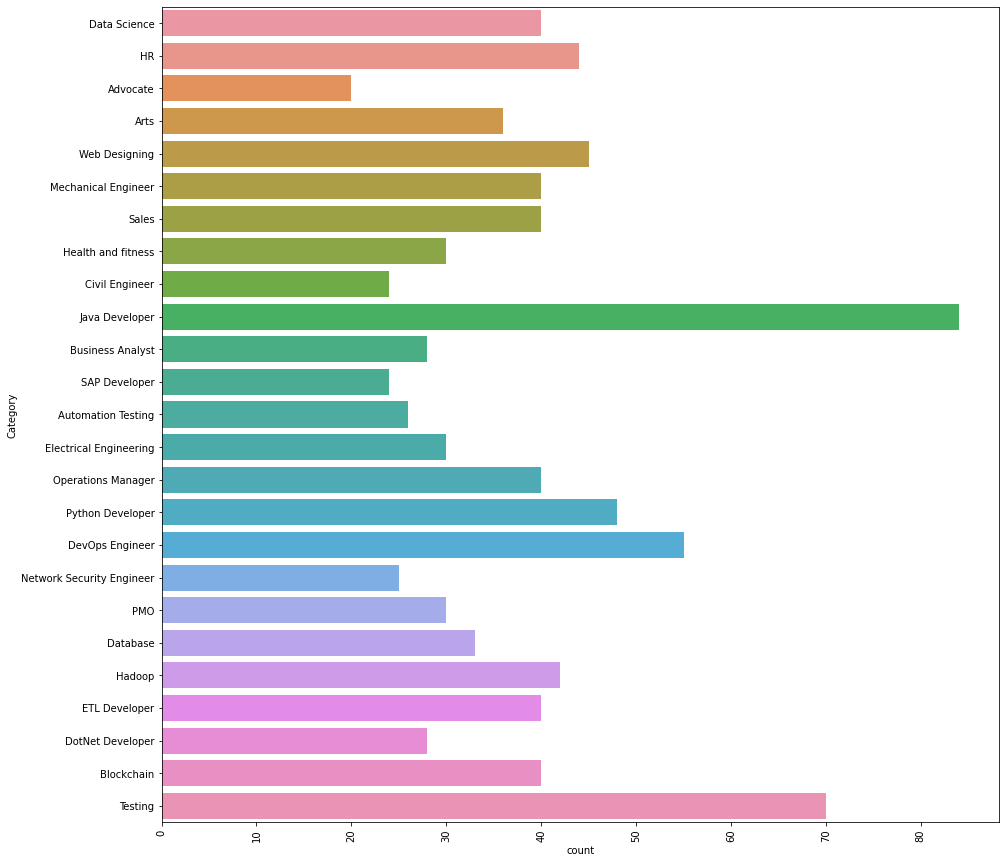

In [8]:
plt.figure(figsize=(15,15))
plt.xticks(rotation=90)
sns.countplot(y="Category",data=resumeDataSet)

#### Now let’s visualize the distribution of categories:

#### Şimdi kategorilerin dağılımını görselleştirelim:

In [9]:
from matplotlib.gridspec import GridSpec

In [10]:
targetCounts=resumeDataSet["Category"].value_counts()

In [11]:
targetLabels=resumeDataSet["Category"].unique()

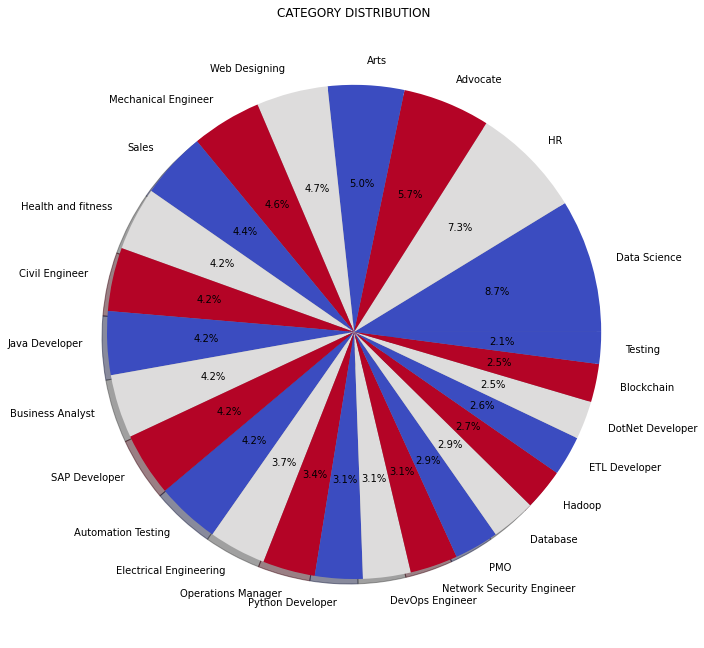

In [12]:
plt.figure(1,figsize=(25,25))
the_grid=GridSpec(2,2)

cmap = plt.get_cmap('coolwarm')
colors = [cmap(i) for i in np.linspace(0, 1, 3)]
plt.subplot(the_grid[0, 1], aspect=1, title='CATEGORY DISTRIBUTION')

source_pie=plt.pie(targetCounts,labels=targetLabels,autopct='%1.1f%%', shadow=True, colors=colors)
plt.show()

#### Now I will create a helper function to remove the URLs, hashtags, mentions, special letters, and punctuations:

#### Şimdi URL'leri, hashtag'leri, sözleri, özel harfleri ve noktalama işaretlerini kaldırmak için bir yardımcı fonksiyon oluşturacağım:

In [13]:
import re
def cleanResume(resumeText):
    resumeText = re.sub('http\S+\s*', ' ', resumeText)  # remove URLs
    resumeText = re.sub('RT|cc', ' ', resumeText)  # remove RT and cc
    resumeText = re.sub('#\S+', '', resumeText)  # remove hashtags
    resumeText = re.sub('@\S+', '  ', resumeText)  # remove mentions
    resumeText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', resumeText)  # remove punctuations
    resumeText = re.sub(r'[^\x00-\x7f]',r' ', resumeText) 
    resumeText = re.sub('\s+', ' ', resumeText)  # remove extra whitespace
    return resumeText

In [14]:
resumeDataSet['cleaned_resume'] = resumeDataSet.Resume.apply(lambda x: cleanResume(x))

#### Now as we have cleared the dataset, the next task is to have a look at the Wordcloud. A Wordcloud represents the most numbers of words larger and vice versa:

#### Şimdi veri kümesini temizlediğimize göre, sıradaki görev Wordcloud'a bir göz atmak. Bir Wordcloud, en fazla sayıda kelimeyi temsil eder ve bunun tersi de geçerlidir:

In [15]:
import nltk
from nltk.corpus import stopwords
import string
from wordcloud import WordCloud

In [16]:
oneSetOfStopWords = set(stopwords.words('english')+['``',"''"])

In [17]:
totalWords =[]

In [18]:
Sentences = resumeDataSet['Resume'].values

In [19]:
cleanedSentences = ""

In [20]:
for i in range(0,160):
    cleanedText = cleanResume(Sentences[i])
    cleanedSentences += cleanedText
    requiredWords = nltk.word_tokenize(cleanedText)
    for word in requiredWords:
        if word not in oneSetOfStopWords and word not in string.punctuation:
            totalWords.append(word)

In [21]:
wordfreqdist = nltk.FreqDist(totalWords)

In [22]:
mostcommon = wordfreqdist.most_common(50)

In [23]:
mostcommon

[('Details', 484),
 ('Exprience', 446),
 ('months', 376),
 ('company', 330),
 ('description', 310),
 ('1', 290),
 ('year', 232),
 ('January', 216),
 ('Less', 204),
 ('Data', 200),
 ('data', 192),
 ('Skill', 166),
 ('Maharashtra', 166),
 ('6', 164),
 ('Python', 156),
 ('Science', 154),
 ('I', 146),
 ('Education', 142),
 ('College', 140),
 ('The', 126),
 ('project', 126),
 ('like', 126),
 ('Project', 124),
 ('Learning', 116),
 ('India', 114),
 ('Machine', 112),
 ('University', 112),
 ('Web', 106),
 ('using', 104),
 ('monthsCompany', 102),
 ('B', 98),
 ('C', 98),
 ('SQL', 96),
 ('time', 92),
 ('learning', 90),
 ('Mumbai', 90),
 ('Pune', 90),
 ('Arts', 90),
 ('A', 84),
 ('application', 84),
 ('Engineering', 78),
 ('24', 76),
 ('various', 76),
 ('Software', 76),
 ('Responsibilities', 76),
 ('Nagpur', 76),
 ('development', 74),
 ('Management', 74),
 ('projects', 74),
 ('Technologies', 72)]

In [24]:
wc = WordCloud().generate(cleanedSentences)

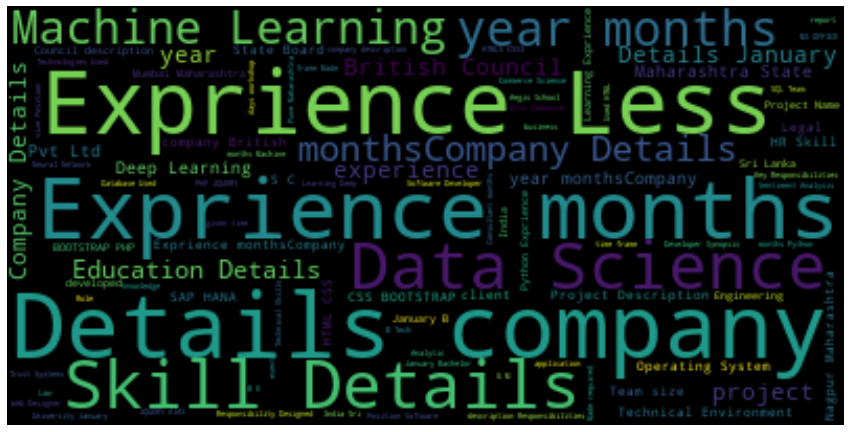

In [25]:
plt.figure(figsize=(15,15))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

#### Now I will convert these words into categorical values:

#### Şimdi bu kelimeleri kategorik değerlere çevireceğim:

In [26]:
from sklearn.preprocessing import LabelEncoder

In [27]:
var_mod = ['Category']
le = LabelEncoder()

In [28]:
for i in var_mod:
    resumeDataSet[i] = le.fit_transform(resumeDataSet[i])

# Training Machine Learning Model for Resume Screening
#### Now the next step in the process is to train a model for the task of Resume Screening. Here I will use the one vs the rest classifier; KNeighborsClassifier. For this task, I will first split the data into training and test sets:

# Özgeçmiş Tarama için Makine Öğrenimi Modelinin Eğitimi
#### Şimdi süreçteki bir sonraki adım, Özgeçmiş Taraması görevi için bir model eğitmektir. Burada bire karşı kalan sınıflandırıcıyı kullanacağım; KNeighborsClassifier. Bu görev için önce verileri eğitim ve test setlerine böleceğim:

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

In [30]:
requiredText = resumeDataSet['cleaned_resume'].values

In [31]:
requiredTarget = resumeDataSet['Category'].values

In [32]:
word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    stop_words='english',
    max_features=1500)
word_vectorizer.fit(requiredText)

TfidfVectorizer(max_features=1500, stop_words='english', sublinear_tf=True)

In [33]:
WordFeatures = word_vectorizer.transform(requiredText)

In [34]:
X_train,X_test,y_train,y_test = train_test_split(WordFeatures,requiredTarget,random_state=0, test_size=0.2)

In [35]:
X_train.shape

(769, 1500)

In [36]:
X_test.shape

(193, 1500)

#### Now let’s train the model and print the classification report:

#### Şimdi modeli eğitelim ve sınıflandırma raporunu yazdıralım:

In [37]:
clf = OneVsRestClassifier(KNeighborsClassifier())

In [38]:
clf.fit(X_train, y_train)

OneVsRestClassifier(estimator=KNeighborsClassifier())

In [39]:
prediction = clf.predict(X_test)

In [40]:
print('Accuracy of KNeighbors Classifier on training set: {:.2f}'.format(clf.score(X_train, y_train)))

Accuracy of KNeighbors Classifier on training set: 0.99


In [41]:
print('Accuracy of KNeighbors Classifier on test set: {:.2f}'.format(clf.score(X_test, y_test)))

Accuracy of KNeighbors Classifier on test set: 0.99


In [42]:
print("\n Classification report for classifier %s:\n%s\n" % (clf, metrics.classification_report(y_test, prediction)))


 Classification report for classifier OneVsRestClassifier(estimator=KNeighborsClassifier()):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3
           2       1.00      0.80      0.89         5
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         6
           5       0.83      1.00      0.91         5
           6       1.00      1.00      1.00         9
           7       1.00      1.00      1.00         7
           8       1.00      0.91      0.95        11
           9       1.00      1.00      1.00         9
          10       1.00      1.00      1.00         8
          11       0.90      1.00      0.95         9
          12       1.00      1.00      1.00         5
          13       1.00      1.00      1.00         9
          14       1.00      1.00      1.00         7
          15       1.00      1.00      1.